In [1]:
import librosa
import numpy as np
import torch
import cv2
import os

n_seconds=4
#num_frames=8
#num_frames=16
num_frames=12
#sr=22050
#sr=44100
sr=32000

#n_mels=224
n_mels=320
channels=1
use_sigmoid=True


In [2]:
USE_EX=False
USE_EX2=False
USE_EX3=False
USE_GAN=False
USE_GAN_RGB=False
if USE_EX2:
    from video_to_spectrogram_sequence_ex import video_to_spectrogram_sequence
    from VideoAutoEncoder_ex2 import VideoAutoEncoder
    MODEL_PATH = "output-8frame4sec-32k-ex2/best_loss_model.pth"  # 保存したモデルのパス
elif USE_EX3:
    from video_to_spectrogram_sequence_ex import video_to_spectrogram_sequence
    from VideoAutoEncoder_ex3 import VideoAutoEncoder
    #MODEL_PATH = "output-8frame4sec-32k-ex/best_loss_model.pth"  # 保存したモデルのパス
    MODEL_PATH = "output/best_loss_model.pth"  # 保存したモデルのパス
elif USE_GAN:
    from video_to_spectrogram_sequence_ex import video_to_spectrogram_sequence
    from VideoAutoEncoder_gan import VideoAutoEncoder
    #MODEL_PATH = "output-8frame4sec-32k-ex/best_loss_model.pth"  # 保存したモデルのパス
    MODEL_PATH = "output/best_loss_model.pth"  # 保存したモデルのパス
    #MODEL_PATH = "output/latest_model.pth"

elif USE_GAN_RGB:
    from video_to_spectrogram_sequence_ex import video_to_spectrogram_sequence
    from VideoAutoEncoder_gan_rgb import VideoAutoEncoder
    #MODEL_PATH = "output-8frame4sec-32k-ex/best_loss_model.pth"  # 保存したモデルのパス
    #MODEL_PATH = "output/best_loss_model.pth"  # 保存したモデルのパス
    MODEL_PATH = "output/latest_model.pth"
    channels=3
    n_mels=224

elif USE_EX:
    from video_to_spectrogram_sequence_ex import video_to_spectrogram_sequence
    from VideoAutoEncoder_ex import VideoAutoEncoder
    #MODEL_PATH = "output-8frame4sec-32k-ex/best_loss_model.pth"  # 保存したモデルのパス
    #MODEL_PATH = "output/best_loss_model.pth"  # 保存したモデルのパス
    MODEL_PATH = "output/latest_model.pth"
    channels=3
    n_mels=224
else:
    from video_to_spectrogram_sequence import video_to_spectrogram_sequence
    from VideoAutoEncoder import VideoAutoEncoder
    #MODEL_PATH = "output-8frame4sec-32k-ex/best_loss_model.pth"  # 保存したモデルのパス
    #MODEL_PATH = "output/best_loss_model.pth"  # 保存したモデルのパス
    MODEL_PATH = "output/latest_model.pth"
    channels=3
    n_mels=224
    num_frames=8
    sr=22050

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if USE_GAN_RGB:
    model = VideoAutoEncoder(num_frames=num_frames,n_mels=224)
    #model = VideoAutoEncoder()
else:
    model = VideoAutoEncoder()
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.to(DEVICE)

# Datasetの__init__等で
hop_length = int((n_seconds * sr) / (num_frames * n_mels)) 
# 約 49 になります。これなら4秒の音が1792ピクセルにピッタリ収まります。
print('hop_length:',hop_length)  # 8frames -> 49



hop_length: 49


In [3]:
import matplotlib.pyplot as plt

def check_spect(anomaly_video_path, n_seconds=4, L_frames=12,hop_length=33 ,sr=32000,n_mels=320,use_color=True):
    # 1. 学習時と同じ関数で前処理
    # [L, 3, 224, 224] の numpy 配列が返る
    anomaly_frames = video_to_spectrogram_sequence(anomaly_video_path, n_seconds=n_seconds, L_frames=num_frames,hop_length=hop_length ,sr=sr,n_mels=n_mels)
    
    # 2. 正規化を戻すための値
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    mean_r = mean[2] # 0.485
    std_r = std[2]   # 0.229
    
    # 2. テンソル化してモデルへ
    # [1, L, 3, 224, 224] に変換
    anomaly_tensor = torch.from_numpy(anomaly_frames).unsqueeze(0).to(DEVICE)
    inputs=anomaly_tensor
    #print('inputs.shape:',inputs.shape)  # inputs.shape: torch.Size([1, 12, 3, 320, 320])
    # 推論モードで1バッチ分だけ取り出す
    model.eval()
    with torch.no_grad():
        # データローダーから1つ取り出す (inputsの形は [batch, frames, 1, 320, 320])
        #inputs = next(iter(train_loader)) 
        #inputs = inputs.to(device)
        # 復元
        outputs = model(anomaly_tensor)
        # 入力のRチャンネル [1, L, 1, 224, 224] と比較
        if channels==3:
            target = anomaly_tensor
        else:
            target = anomaly_tensor[:, :, 0:1, :, :]
        anomaly_loss = torch.nn.functional.mse_loss(outputs , target).item()
        #anomaly_loss = torch.nn.functional.l1_loss(outputs, target).item()
    
        #print('inputs.shape:',inputs.shape)  # inputs.shape: torch.Size([1, 12, 3, 320, 320])
        # 最初のデータの、最初のフレーム [0, 0] を取り出してCPUへ
    
        if not use_color:
            #print('inputs.shape:',inputs.shape)  # inputs.shape: torch.Size([1, 12, 3, 320, 320])
            if USE_RGB:
                target = inputs
            else:
                target = inputs[:, :, 0:1, :, :]
            #original_img = inputs[0,0].permute(1, 2, 0).cpu().numpy()
            original_img = target[0,0].permute(1, 2, 0).cpu().numpy()
            #print('original_img.shape:',original_img.shape)  # original_img.shape: (320, 320, 3) -> original_img.shape: (320, 320, 1)
            if USE_RGB:
                original_img = (original_img * std) + mean
            else:
                original_img = (original_img * std_r) + mean_r
            original_img = np.clip(original_img, 0, 1)
    
            #print('outputs.shape:',outputs.shape)  # outputs.shape: torch.Size([1, 12, 1, 320, 320])
            recon_img = outputs[0,0].permute(1, 2, 0).cpu().numpy()
            #print('recon_img.shape:',recon_img.shape)  # recon_img.shape: (320, 320, 1)
            if USE_RGB:
                recon_img = (recon_img * std) + mean
            else:
                #print("Recon値の範囲:", recon_img.min(), "~", recon_img.max())
                recon_img = (recon_img * std_r) + mean_r
            #print("Recon値の範囲2:", recon_img.min(), "~", recon_img.max())
            recon_img = np.clip(recon_img, 0, 1)
           
            # 並べて表示
            plt.figure(figsize=(10, 5))
            plt.subplot(1, 2, 1)
            plt.title("Original")
            #plt.imshow(original_img, aspect='auto', origin='lower')
            plt.imshow(original_img, aspect='auto', cmap='gray',origin='lower')
            
            plt.subplot(1, 2, 2)
            plt.title("Reconstructed")
            #plt.imshow(recon_img, aspect='auto', origin='lower')
            #plt.imshow(recon_img, aspect='auto', cmap='gray',origin='lower')
            plt.imshow(recon_img.squeeze(), aspect='auto', cmap='gray', origin='lower') # squeeze() で (320, 320) にする
            #plt.imshow(recon_img.squeeze(), cmap='gray', origin='lower', vmin=0, vmax=1)
            plt.show()
        
        else:
            fn=0
            #print('inputs.shape:',inputs.shape)  # inputs.shape: torch.Size([1, 12, 3, 320, 320])
            if channels==3:
                original_img = inputs[0,fn].permute(1, 2, 0).cpu().numpy()
            else:
                original_img = inputs[0,fn,0].cpu().numpy() # [320, 320] を取り出す
            #print('original_img.shape:',original_img.shape)  # original_img.shape: (320, 320, 3) original_img.shape: (3, 224, 224)
            original_img = np.clip(original_img, 0, 1)
    
            #print('outputs.shape:',outputs.shape)  # outputs.shape: torch.Size([1, 12, 1, 320, 320])
            # 修正後の表示用コード
            recon_img = outputs[0,0].permute(1, 2, 0).cpu().numpy()
            #print('recon_img.shape:',recon_img.shape)  # original_img.shape: (320, 320)
            if channels==3:
                recon_img_raw = outputs[0,fn].permute(1, 2, 0).cpu().numpy()
            else:
                recon_img_raw = outputs[0,fn,0].cpu().numpy() # [320, 320] を取り出す
            #print('recon_img_raw.shape:',recon_img_raw.shape)  # original_img.shape: (320, 320)
            recon_img_raw = np.clip(recon_img_raw, 0, 1)
            
            plt.figure(figsize=(10, 5))
            plt.subplot(1, 2, 1)
            plt.title("Original (Colorized)")
            #plt.imshow(original_img, origin='lower') # 正規化を解いたカラー画像
            plt.imshow(original_img, cmap='magma', origin='lower', vmin=0, vmax=1) # 正規化を解いたカラー画像
            
            plt.subplot(1, 2, 2)
            plt.title("Reconstructed (Raw)")
            # 加工せず、0-1の範囲を固定して表示
            plt.imshow(recon_img_raw, cmap='magma', origin='lower', vmin=0, vmax=1)
            #plt.colorbar() # 値の範囲を確認するために追加
            plt.show()

    return anomaly_loss

def check_dir(data_dir,flist,title_s):
    # 再現テスト用のコード例
    model.eval() # 評価モード（学習しない）
    normal_loss_list=[]
    
    with torch.no_grad():
        # 学習に使ったのと「同じ動画」をDatasetから1つ取り出す
        for s in flist:
            video_path=data_dir+'/'+s
            anomaly_frames = video_to_spectrogram_sequence(video_path, n_seconds=4, L_frames=num_frames,hop_length=hop_length ,sr=sr,n_mels=n_mels)
            anomaly_tensor = torch.from_numpy(anomaly_frames).unsqueeze(0).to(DEVICE)
            # モデルに通す
            outputs = model(anomaly_tensor)
            # 誤差を計算
            if channels==3:
                target = anomaly_tensor
            else:
                target = anomaly_tensor[:, :, 0:1, :, :]
            #normal_loss = criterion(outputs, target).item()
            normal_loss = torch.nn.functional.mse_loss(outputs , target).item()  # avg_loss と同じ
            #_loss = torch.nn.functional.l1_loss(outputs, target).item()
    
            # 誤差を計算
            if channels==3:
                target2 = anomaly_tensor.detach().cpu().numpy().copy()
            else:
                #target2 = anomaly_tensor[:, :, 0:1, :, :].detach().cpu().numpy()
                target2 = anomaly_tensor[:, :, 0:1, :, :].detach().cpu().numpy().copy()
            #print('type(target2):',type(target2))
            #outputs = outputs.cpu().numpy()
            outputs2 = outputs.detach().cpu().numpy().copy()
            # 差分を計算
            diff_sq = (outputs2 - target2) ** 2
            # フレームごとのLoss [Batch, Time]
            # axis=(2, 3, 4) は [Channel, Height, Width] の軸をすべて平均化するという意味です
            frame_losses = np.mean(diff_sq, axis=(2, 3, 4))[0] 
            # 【ここが重要】平均ではなく最大値を取る
            max_loss = np.max(frame_losses)
            avg_loss = np.mean(frame_losses) # 参考に平均も出す
            print(f"{title_s}_loss:{normal_loss:.6f} max_loss: {max_loss:.6f} avg_loss:{avg_loss:.6f} {s}")
            
            normal_loss_list.append(normal_loss)
            
    normal_loss = sum(normal_loss_list) / len(normal_loss_list)
    normal_loss_min = min(normal_loss_list)
    normal_loss_max = max(normal_loss_list)
    print(f"{title_s}の Loss: {normal_loss:.6f}")
    print(f"{title_s}の Loss min: {normal_loss_min:.6f}")
    print(f"{title_s}の Loss max: {normal_loss_max:.6f}")
    

hop_length: 49


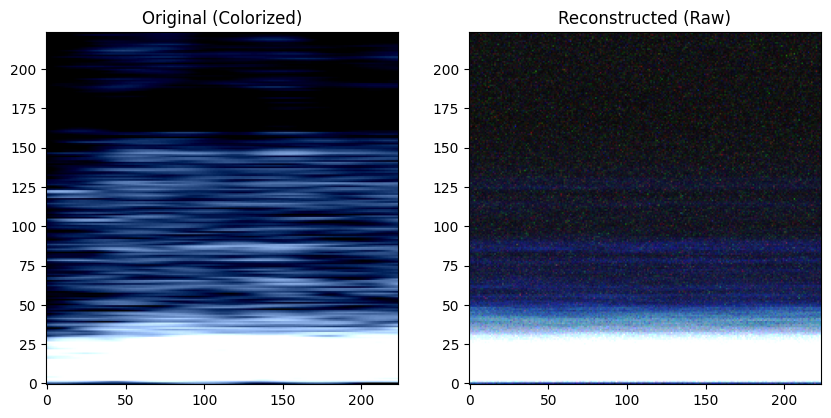

datasets/bike/normal/HGUwKAq1kxk_trim1.mp4
【判定テスト】
今回のスコア : 0.100520
結果: 正常範囲内です。


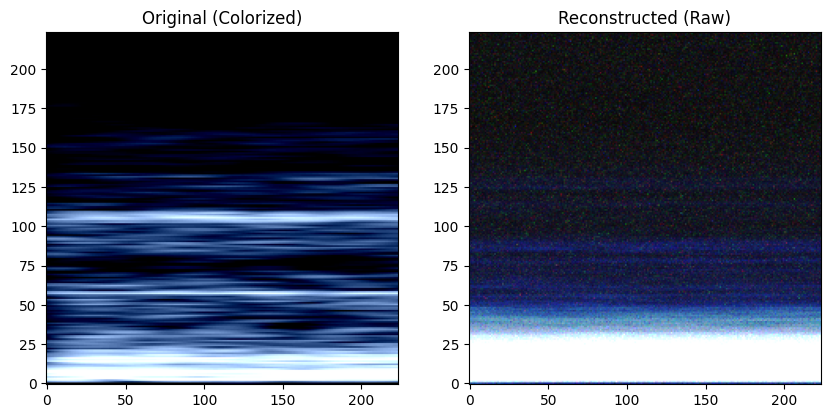

datasets/bike/speed/backup/iCCc6tsElTk_trim1.mp4
【判定テスト】
今回のスコア : 0.322260
結果: 異常（または未学習の動作）を検知しました！


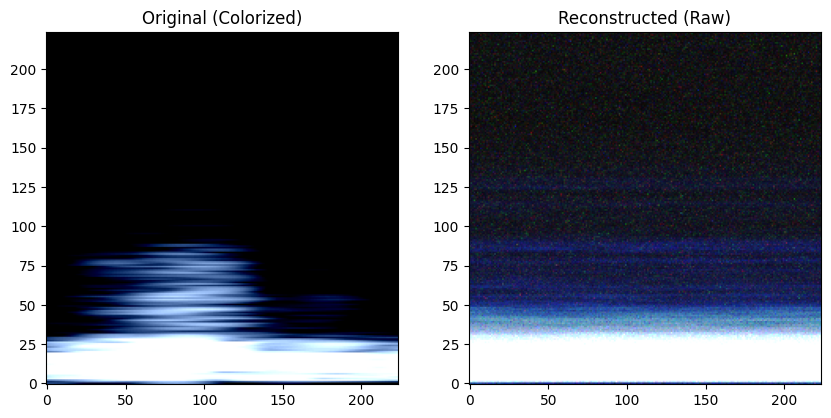

datasets/bike/speed/RnSyCz9ERMw.mp4_trim1.mp4
【判定テスト】
今回のスコア : 1.223727
結果: 異常（または未学習の動作）を検知しました！


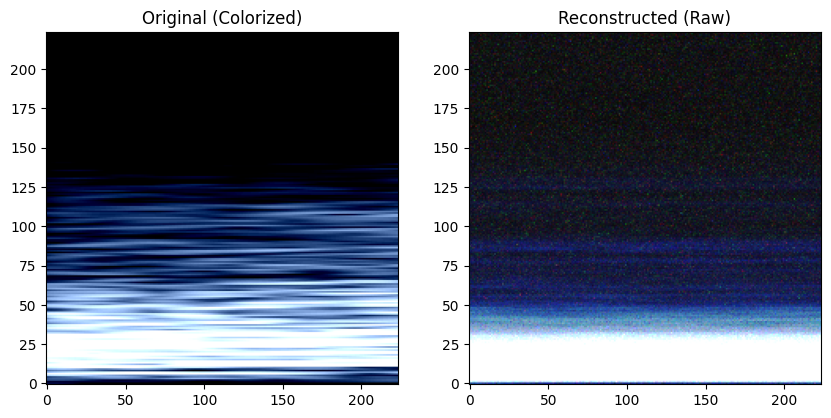

datasets/bike/speed/yL7jbivvApg_trim3.mp4
【判定テスト】
今回のスコア : 0.675672
結果: 異常（または未学習の動作）を検知しました！


In [4]:
import matplotlib.pyplot as plt

anomaly_video_path = "datasets/bike/speed/backup/iCCc6tsElTk_trim1.mp4"
#anomaly_video_path = "datasets/bike/speed/RnSyCz9ERMw.mp4_trim1.mp4"
#anomaly_video_path = "datasets/bike/speed/yL7jbivvApg_trim3.mp4"
#anomaly_video_path = "datasets/bike/speed/iCCc6tsElTk_trim2.mp4"
#anomaly_video_path = "datasets/bike/normal/HGUwKAq1kxk_trim1.mp4"
#hop_length=49
#hop_length=24
#hop_length=16
hop_length = int((n_seconds * sr) / (num_frames * n_mels)) 
# 約 49 になります。これなら4秒の音が1792ピクセルにピッタリ収まります。
print('hop_length:',hop_length)  # 8frames -> 49

anomaly_video_path_list=[
    "datasets/bike/normal/HGUwKAq1kxk_trim1.mp4",
    "datasets/bike/speed/backup/iCCc6tsElTk_trim1.mp4",
    "datasets/bike/speed/RnSyCz9ERMw.mp4_trim1.mp4",
    "datasets/bike/speed/yL7jbivvApg_trim3.mp4",
    #"datasets/bike/speed/iCCc6tsElTk_trim2.mp4",
    ]

for s in  anomaly_video_path_list:
    anomaly_loss = check_spect(s, n_seconds=n_seconds, L_frames=num_frames,hop_length=hop_length ,sr=sr,n_mels=n_mels,use_color=True)
    print(s)
    print(f"【判定テスト】")
    #print(f"正常（アイドリング）の基準スコア: 0.316097")
    print(f"今回のスコア : {anomaly_loss:.6f}")
    
    # 簡易判定
    #threshold = 0.107949 # 仮のしきい値
    threshold = 0.256570
    #threshold = 0.3 # 仮のしきい値
    if anomaly_loss > threshold:
        print("結果: 異常（または未学習の動作）を検知しました！")
    else:
        print("結果: 正常範囲内です。")

In [5]:
data_dir = os.path.join("datasets","bike", "normal")
#flist=os.listdir(data_dir)
flist = [f for f in os.listdir(data_dir) if f.endswith(".mp4") or f.endswith(".wav")]

check_dir(data_dir,flist,"normal")


normal_loss:0.256570 max_loss: 0.310370 avg_loss:0.256570 kfRclYT_1aw_trim1.mp4
normal_loss:0.125218 max_loss: 0.148532 avg_loss:0.125218 HGUwKAq1kxk_trim4.mp4
normal_loss:0.148228 max_loss: 0.178276 avg_loss:0.148228 hY8LJ_eyMw4_trim1.mp4
normal_loss:0.113807 max_loss: 0.121901 avg_loss:0.113807 HGUwKAq1kxk_trim2.mp4
normal_loss:0.110732 max_loss: 0.120796 avg_loss:0.110732 yL7jbivvApg_trim1.mp4
normal_loss:0.100520 max_loss: 0.113504 avg_loss:0.100520 HGUwKAq1kxk_trim1.mp4
normal_loss:0.156424 max_loss: 0.184572 avg_loss:0.156424 HGUwKAq1kxk_trim3.mp4
normalの Loss: 0.144500
normalの Loss min: 0.100520
normalの Loss max: 0.256570


In [6]:
data_dir = os.path.join("datasets","bike", "speed2")
#data_dir = os.path.join("datasets","bike", "speed")
#flist=os.listdir(data_dir)
flist = [f for f in os.listdir(data_dir) if f.endswith(".mp4") or f.endswith(".wav")]

check_dir(data_dir,flist,"speed")


speed_loss:0.675672 max_loss: 0.886656 avg_loss:0.675672 yL7jbivvApg_trim3.mp4
speed_loss:0.704238 max_loss: 1.421105 avg_loss:0.704238 iCCc6tsElTk_trim2.mp4
speed_loss:1.223727 max_loss: 1.466471 avg_loss:1.223727 RnSyCz9ERMw.mp4_trim1.mp4
speed_loss:0.322260 max_loss: 0.413581 avg_loss:0.322260 iCCc6tsElTk_trim1.mp4
speedの Loss: 0.731474
speedの Loss min: 0.322260
speedの Loss max: 1.223727
